# Media Source Extraction Pipeline
 
```
Setup & data load
  → Step 1:  Split cells into individual source candidates
  → Step 2:  Clean each string
  → Step 3:  Frequency table + distribution chart
  → Step 3a: Visualise distribution (how many sources vs how many mentions) 
  → Step 4:  Extract frequent words (≥4 mentions) from long sentences → new freq table + chart 
  → Step 5: Social-media column audit — what did people write in Facebook/Instagram/etc? 
  → Step 6:  Unification
```

# Setup and data load

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

df = pd.read_csv('media_sources_internship.csv')
print(df.shape)
print(list(df.columns))

(928, 21)
['PROLIFIC_PID', 'Facebook', 'Facebook_freq', 'Instagram', 'Instagram_freq', 'TV news programs', 'TV news programs_freq', 'TikTok', 'TikTok_freq', 'Twitter/X', 'Twitter/X_freq', 'YouTube', 'YouTube_freq', 'online news sites', 'online news sites_freq', 'podcasts', 'podcasts_freq', 'printed newspapers', 'printed newspapers_freq', 'the radio', 'the radio_freq']


In [2]:
# Survey columns where the platform itself is social media
SM_SURVEY_COLS = ['Facebook', 'Instagram', 'TikTok', 'Twitter/X', 'YouTube']

# Survey columns for traditional media
MM_SURVEY_COLS = ['TV news programs', 'online news sites', 'podcasts',
                  'printed newspapers', 'the radio']

# All free-text columns (drop ID and pre-aggregated freq columns)
source_cols = [c for c in df.columns
               if not c.endswith('_freq') and c != 'PROLIFIC_PID']

# Stack into one long Series, keep track of which column each entry came from
all_text_with_col = (
    df[source_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'survey_col', 0: 'text'})
    .assign(text=lambda d: d['text'].astype(str))
)
all_text = all_text_with_col['text']
print(f"Total cells: {len(all_text)}")

Total cells: 2771


# Step 1: Split cells into individual source candidates

Cells contain multiple sources separated by commas, semicolons, newlines, or 'and'.
'and' is tricky — only split on it when the text to the left is ≤30 chars (likely a short name, not a sentence).
Sources whose names contain 'and' go in PROTECTED_NAMES — never split those.

In [3]:
PROTECTED_NAMES = {
    'aba and preach',
    'faith and freedom coalition',
    'guns and butter',
    'law and crime',
    'crime and justice',
    'meet the press',
    'msnbc',  # kept separate — 'meet the press' is a program, 'msnbc' is a channel
    'breaking points with krystal and saagar',
}

def split_sources(text):
    # Split on clear delimiters — never part of a source name
    segs = re.split(r'[;,\n:/]|\.\.\.+', text)
    result = []
    for seg in segs:
        if seg.strip().lower() in PROTECTED_NAMES:
            result.append(seg)
            continue
        parts = re.split(r'\s+and\s+', seg, flags=re.IGNORECASE)
        if len(parts) == 1:
            result.append(seg)
        else:
            current = parts[0]
            for nxt in parts[1:]:
                if len(current.strip()) <= 30:
                    # Short left side → 'and' is a list separator, e.g. 'CNN and BBC'
                    result.append(current)
                    current = nxt
                else:
                    # Long left side → 'and' is part of the text, keep together
                    current = current + ' and ' + nxt
            result.append(current)
    return [s.strip() for s in result if s.strip()]

# Quick checks
tests = [
    ("CNN, BBC and Fox",            "expect 3"),
    ("NYT; Washington Post; NPR",   "expect 3"),
    ("Aba and Preach, NYT",         "expect 2 — Aba and Preach stays whole"),
    ("CNN\nBBC\nFox",               "expect 3 from newlines"),
]
for text, note in tests:
    print(f"  {note}: {split_sources(text)}")

  expect 3: ['CNN', 'BBC', 'Fox']
  expect 3: ['NYT', 'Washington Post', 'NPR']
  expect 2 — Aba and Preach stays whole: ['Aba and Preach', 'NYT']
  expect 3 from newlines: ['CNN', 'BBC', 'Fox']


# Step 2: Clean each candidate string

Lowercase, strip URLs, remove domain endings, remove noise punctuation.
Also record which survey column the entry came from — needed later for MM-in-SM detection.

In [4]:
def clean(s):
    s = s.lower()
    s = re.sub(r'https?://|www\.|//', '', s)
    # .co.uk before .co so we catch the full thing
    s = re.sub(r'\.co\.uk|\.com|\.org|\.net|\.co|\.uk|\.gov|\.edu', '', s)
    s = s.replace('_', ' ')
    s = re.sub(r'[@™\'\"()\[\]]', '', s)
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.strip(' /-.')
    return s

# Explode: one row per split+cleaned piece, keeping survey_col
rows = []
for _, row in all_text_with_col.iterrows():
    for piece in split_sources(row['text']):
        c = clean(piece)
        if c:
            rows.append({
                'cleaned':    c,
                'survey_col': row['survey_col'],
                'col_type':   'SM_col' if row['survey_col'] in SM_SURVEY_COLS else 'MM_col',
            })

exploded = pd.DataFrame(rows)
all_cleaned = exploded['cleaned']

print(f"Total mentions (with repeats): {len(all_cleaned)}")
print(f"Unique strings: {all_cleaned.nunique()}")

Total mentions (with repeats): 6355
Unique strings: 2506


# Step 3: Frequency table

Count how often each unique string appears.
We focus on strings mentioned 4+ times — these are the ones worth spending effort on.

In [5]:
freq = all_cleaned.value_counts().reset_index()
freq.columns = ['source', 'count']
freq['cumulative_pct'] = (freq['count'].cumsum() / freq['count'].sum() * 100).round(1)

top = freq[freq['count'] >= 4].copy()
print(f"Strings mentioned 4+ times: {len(top)}")
print(f"These cover {top['count'].sum()} of {len(all_cleaned)} total mentions "
      f"({top['count'].sum()/len(all_cleaned)*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top.to_string())

Strings mentioned 4+ times: 161
These cover 3629 of 6355 total mentions (57.1%)

                      source  count  cumulative_pct
0                        cnn    623             9.8
1                   fox news    188            12.8
2                      msnbc    184            15.7
3                        npr    157            18.1
4             new york times    139            20.3
5                        bbc    130            22.4
6                        nbc    114            24.2
7                        abc    106            25.8
8            washington post     89            27.2
9                        fox     89            28.6
10                       cbs     81            29.9
11                   reuters     64            30.9
12                  abc news     52            31.7
13               google news     45            32.4
14                      cnbc     44            33.1
15        the new york times     44            33.8
16       wall street journal     44

In [6]:
len(top)

161

# Step 3a: Distribution chart

X axis = number of mentions (count).
Y axis = how many unique strings have that count.
This shows whether the data is dominated by a few very common sources or spread across many rare ones.

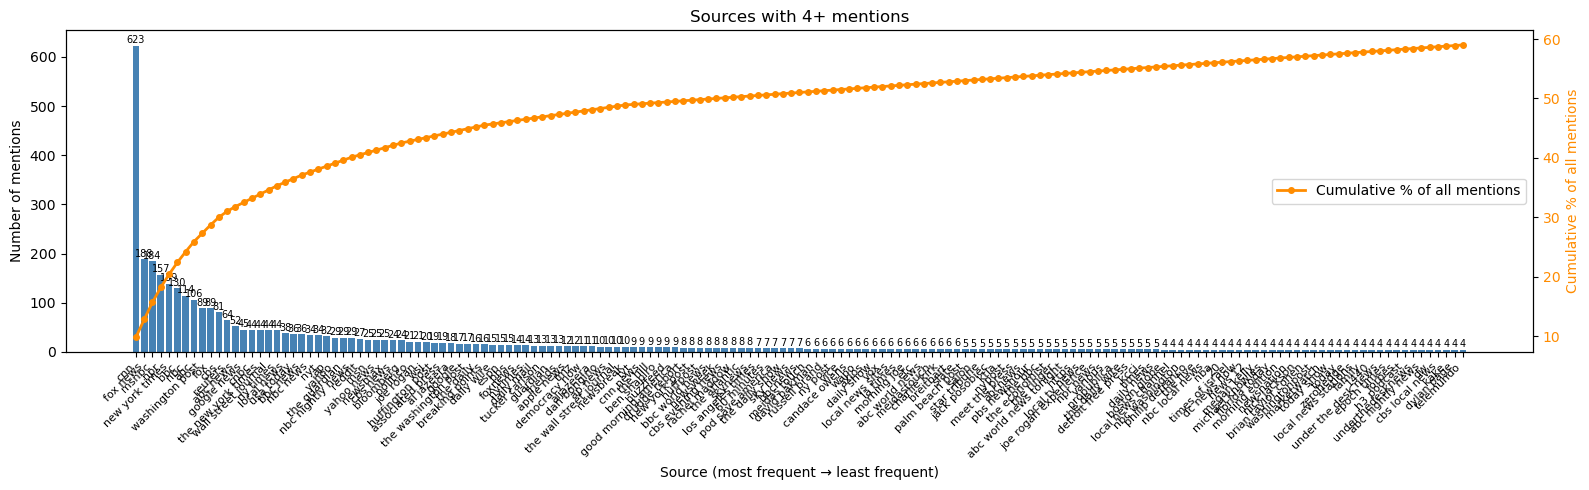

Total mentions in dataset: 6355

  Top  1 sources cover 623 of 6355 mentions (9.8%)
  Top  5 sources cover 1291 of 6355 mentions (20.3%)
  Top 10 sources cover 1819 of 6355 mentions (28.6%)
  Top 20 sources cover 2311 of 6355 mentions (36.4%)
  Top 40 sources cover 2819 of 6355 mentions (44.4%)
  Top 80 sources cover 3240 of 6355 mentions (51.0%)
  Top 161 sources cover 3629 of 6355 mentions (57.1%)


In [7]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = freq['count'].sum()
top40 = freq.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with 4+ mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top40['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 3b: How many strings contain 'like' or 'from'?

These are sentences where a source name is embedded after like and from.
We want to know how common it is.

In [8]:
long_strings = all_cleaned

like_mask = long_strings.str.contains(r'\blike\b', regex=True, na=False)
from_mask = long_strings.str.contains(r'\bfrom\b', regex=True, na=False)

print(f"Total cleaned strings:         {len(all_cleaned)}")
print(f"Long strings (>=25 chars):     {len(all_cleaned)} ({len(all_cleaned)/len(all_cleaned)*100:.1f}%)")
print(f"  containing 'like':           {like_mask.sum()}")
print(f"  containing 'from':           {from_mask.sum()}")
print()
print("Sample 'like' sentences:")
for s in long_strings[like_mask].head(8).tolist():
    print(f"  {repr(s)}")
print()
print("Sample 'from' sentences:")
for s in long_strings[from_mask].head(8).tolist():
    print(f"  {repr(s)}")

Total cleaned strings:         6355
Long strings (>=25 chars):     6355 (100.0%)
  containing 'like':           15
  containing 'from':           47

Sample 'like' sentences:
  'show pages that i follow like the black keys'
  'content creators that i follow like arnold'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'entertainment news like movieweb'
  'entertainment news from various content creators like alanah pearce'
  'news sources on specific issues like woods hole oceanagraphic institute'
  'local news youtube channels like wral'
  'maybe some random other videos like hasan that i only watch occasionally'

Sample 'from' sentences:
  'film news from bands'
  'entertainment news from actors'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'political news from the majority report'
  'entertainment news from various content creators like alanah pearce'
  'just w

# Step 4: Extract frequent words from long sentences

Instead of scanning for known names, we take all strings that appear 4+ times and
look for them as substrings inside the long sentences.
The idea: if 'cnn' is frequent and a sentence contains 'cnn', we extract 'cnn'. 

In [9]:
freq_names = set(freq[freq['count'] >= 4]['source'].tolist())
# We no longer filter by JUNK_WORDS: some words in the list could be part of
# legitimate source names (e.g. 'Fox & Friends' contains 'friends').
# Keeping all frequent strings as candidates is safer; any genuine noise will
# simply stay unresolved and appear infrequently in the final table.
candidate_names = sorted(
    list(freq_names),
    key=len, reverse=True   # longest first — 'new york times' before 'times'
)
print(f"Candidate source names (frequent): {len(candidate_names)}")
print(f"Top 30: {candidate_names[:30]}")

Candidate source names (frequent, not junk): 156
Top 30: ['the wall street journal', 'abc world news tonight', 'good morning america', 'joe rogan experience', 'local news stations', 'under the desk news', 'the washington post', 'wall street journal', 'detroit free press', 'local news channel', 'the new york times', 'brian taylor cohen', 'los angeles times', 'local news sites', 'nbc nightly news', 'cbs evening news', 'associated press', 'abc nightly news', 'underthedesknews', 'pod save america', 'breaking points', 'philip defranco', 'morning edition', 'huffington post', 'palm beach post', 'michael knowles', 'times of israel', 'washington post', 'the daily show', 'bbc world news']


In [10]:
def extract_frequent(s, candidates):
    """Return all frequent names found as whole words inside s.
    If multiple candidates match (e.g. 'bbc or cnn'), each match becomes its own
    row via the explode() call below.  If nothing matches, return s unchanged.
    """
    found = [name for name in candidates
             if re.search(r'\b' + re.escape(name) + r'\b', s)]
    return found if found else [s]

# Explode multi-match results so 'bbc or cnn' → two separate rows
step4_series = all_cleaned.apply(lambda s: extract_frequent(s, candidate_names))
all_extracted_step4 = step4_series.explode().reset_index(drop=True)

# How many strings got resolved (changed)?
original_repeated = all_cleaned.loc[all_cleaned.index.repeat(
    step4_series.apply(len)
)].reset_index(drop=True)
resolved_4 = (all_extracted_step4 != original_repeated).sum()
unresolved_4 = len(all_extracted_step4) - resolved_4

print(f"  Rows after explode:             {len(all_extracted_step4)} (was {len(all_cleaned)})")
print(f"  Resolved by frequent-name scan: {resolved_4} ({resolved_4/len(all_extracted_step4)*100:.1f}%)")
print(f"  Still unresolved:               {unresolved_4}")

# Show some resolved examples
examples_4 = pd.DataFrame({
    'Before': original_repeated.values,
    'After':  all_extracted_step4.values
})
resolved_examples = examples_4[examples_4['Before'] != examples_4['After']]
print(f"\nSample resolved:")
with pd.option_context('display.max_colwidth', 90):
    print(resolved_examples.head(15).to_string())

  Resolved by frequent-name scan: 447 (7.0%)
  Still unresolved:               5908

Sample resolved:
                                                                                                         Before        After
21                                                                                                        abc 7          abc
65                                                                                                   bbc or cnn          cnn
68                                                                                                newyork times        times
87                                                                                                    abc msnbc        msnbc
89                                                                                                  yahoo msnbc        msnbc
99                                                                                                newyork times        times
106                    

In [11]:
# New frequency table after step 4
freq_4 = all_extracted_step4.value_counts().reset_index()
freq_4.columns = ['source', 'count']
freq_4['cumulative_pct'] = (freq_4['count'].cumsum() / freq_4['count'].sum() * 100).round(1)

top_4 = freq_4[freq_4['count'] >= 4].copy()
unique_before = all_cleaned.nunique()
unique_after_4 = all_extracted_step4.nunique()

print(f"Unique strings before step 4: {unique_before}")
print(f"Unique strings after  step 4: {unique_after_4}")
print(f"Reduced by: {unique_before - unique_after_4} ({(unique_before-unique_after_4)/unique_before*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_4.to_string())

Unique strings before step 4: 2506
Unique strings after  step 4: 2129
Reduced by: 377 (15.0%)

                      source  count  cumulative_pct
0                        cnn    642            10.1
1                      msnbc    198            13.2
2                   fox news    195            16.3
3                        npr    182            19.2
4                        bbc    147            21.5
5             new york times    143            23.7
6                        nbc    130            25.8
7                        abc    127            27.8
8                        fox    120            29.6
9                        cbs     98            31.2
10           washington post     93            32.7
11                local news     81            33.9
12                   reuters     65            34.9
13                  abc news     59            35.9
14               google news     52            36.7
15        the new york times     50            37.5
16                   

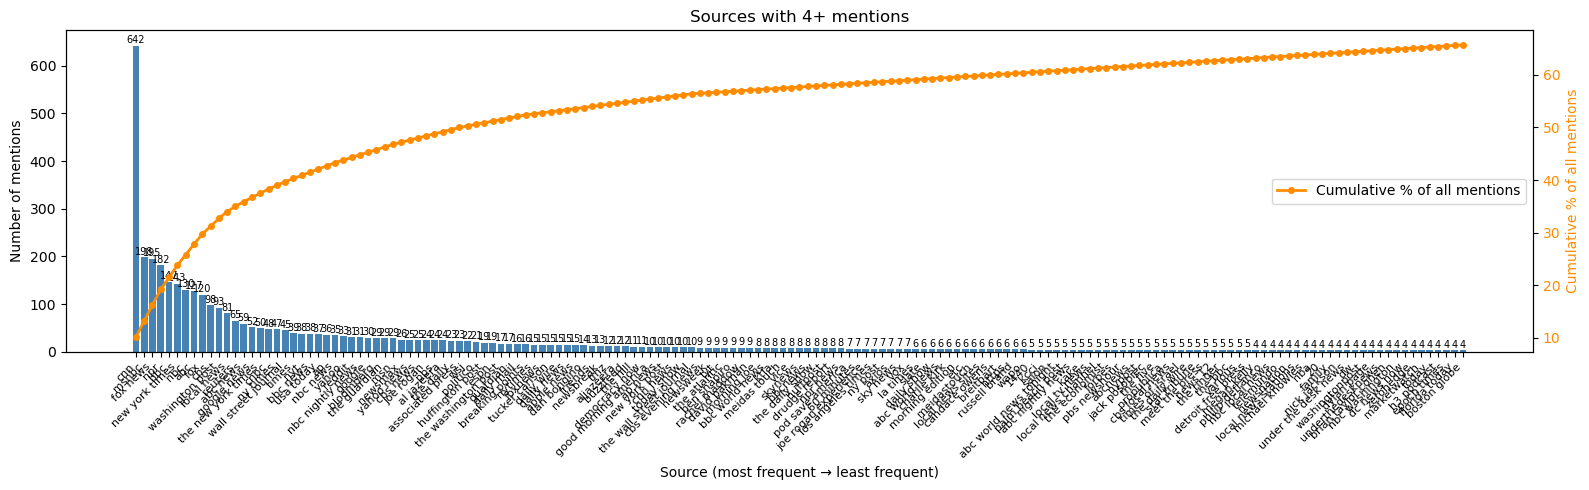

Total mentions in dataset: 6355

  Top  1 sources cover 642 of 6355 mentions (10.1%)
  Top  5 sources cover 1364 of 6355 mentions (21.5%)
  Top 10 sources cover 1982 of 6355 mentions (31.2%)
  Top 20 sources cover 2561 of 6355 mentions (40.3%)
  Top 40 sources cover 3151 of 6355 mentions (49.6%)
  Top 80 sources cover 3649 of 6355 mentions (57.4%)
  Top 161 sources cover 4076 of 6355 mentions (64.1%)


In [12]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = freq_4['count'].sum()
top40 = freq_4.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with 4+ mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top40['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 5 Since most of extracted sources are mainstream media, we'll need to analyse social-media 

What did people actually write in the Facebook / Instagram / TikTok / Twitter / YouTube columns?

We expect SM platform names — but some people wrote mainstream media sources there (e.g. 'CNN' in the YouTube column).
This is 'MM-in-SM': they consume news via a social media platform.
We also check how much is genuine noise (non-news junk).

In [17]:
sm_col_entries = exploded[exploded['col_type'] == 'SM_col']['cleaned'].copy()
# Apply the extraction we've done so far (now returns lists → explode)
sm_col_entries_extracted = (
    sm_col_entries
    .apply(lambda s: extract_frequent(s, candidate_names))
    .explode()
    .reset_index(drop=True)
)

sm_freq = sm_col_entries_extracted.value_counts().reset_index()
sm_freq.columns = ['source', 'count']

# Exclude sources already captured in candidate_names (i.e. MM sources):
# those are 'MM-in-SM' cases and will be analysed separately.
# What remains are the SM-specific strings worth reviewing with Elisa.
sm_freq_specific = sm_freq[~sm_freq['source'].isin(candidate_names)].copy()

print(f"All SM column entries: {len(sm_col_entries_extracted)}")
print(f"Unique SM strings (including MM sources): {sm_freq['source'].nunique()}")
print(f"SM-specific strings (excluding known MM sources): {sm_freq_specific['source'].nunique()}")
print()
print("SM-specific sources (not already in candidate_names):")
sm_freq_specific

,source,count
0,cnn,236
1,bbc,72
2,msnbc,68
3,fox news,52
4,fox,44
...,...,...
1255,wtkr news 3,1
1256,1440,1
1257,i dont go looking anywhere. just if something ...,1
1258,random,1


# Step 6: Map all variants to one standard name
 

In [20]:
# Each entry: (regex pattern, standard name)
# \b = word boundary — \bcnn\b matches 'cnn' but not 'xcnn' or 'cnn2'
ALIAS_MAP = [
    # Exceptions first
    (r'\bfox\s*1[0-9]\b',                   'Fox 13'),           # local affiliates
    (r'\bgoogle\s+discover\b',               'Google Discover'),

    # New York Times
    (r'\bthe\s+new\s+york\s+times?\b',       'New York Times'),
    (r'\bnew\s+york\s+times?\b',             'New York Times'),
    (r'\bnytimes?\b',                        'New York Times'),
    (r'\bny\s+times?\b',                     'New York Times'),
    (r'\bnyt\b',                             'New York Times'),

    # CNN
    (r'\bcnn\s*news?\b',                     'CNN'),
    (r'\bcnn\b',                             'CNN'),

    # Sky News
    (r'\bsky\s*news\b',                      'Sky News'),
    (r'\bskynews\b',                         'Sky News'),

    # Fox News — fox13 already caught above
    # \bfox\b(?!\s*\d) = 'fox' not followed by a number
    (r'\bfox\s+news\b',                      'Fox News'),
    (r'\bfoxnews\b',                         'Fox News'),
    (r'\blivenow\s+from\s+fox\b',            'Fox News'),
    (r'\bfox\b(?!\s*\d)',                    'Fox News'),

    # BBC
    (r'\bbbcnews\b',                         'BBC News'),
    (r'\bbbc\s+world\s+news\b',              'BBC News'),
    (r'\bbbc\s+world\b',                     'BBC News'),
    (r'\bbbc(?:\s+news)?\b',                 'BBC News'),

    # Washington Post
    (r'\bthe\s+washington\s+post\b',         'Washington Post'),
    (r'\bwashington\s+post\b',               'Washington Post'),
    (r'\bwapo\b',                            'Washington Post'),
    (r'\bwashpost\b',                        'Washington Post'),
    (r'\bwashingtonpost\b',                  'Washington Post'),
    (r'\btwp\b',                             'Washington Post'),

    # MSNBC
    (r'\bmsnbc\b',                           'MSNBC'),

    # NBC
    (r'\bnbc\s+nightly\s+news\b',            'NBC News'),
    (r'\bnbc\s+washington\b',                'NBC News'),
    (r'\bnbc(?:\s+news)?\b',                 'NBC News'),

    # ABC
    (r'\babc\s+world\s+news\b',              'ABC News'),
    (r'\bgood\s+morning\s+america\b',        'ABC News'),
    (r'\babc\s*\d+\s*(?:news)?\b',           'ABC News'),  # abc7, abc7news
    (r'\babc(?:\s+news)?\b',                 'ABC News'),

    # CBS
    (r'\bcbs\s+evening\s+news\b',            'CBS News'),
    (r'\b60\s+minutes\b',                    'CBS News'),
    (r'\bcbs(?:\s+news)?\b',                 'CBS News'),

    # NPR — including 'npr (national public radio)' and 'national public radio'
    (r'\bnpr\b',                             'NPR'),
    (r'\bnational\s+public\s+radio\b',       'NPR'),

    # PBS
    (r'\bpbs(?:\s+news(?:hour)?)?\b',        'PBS NewsHour'),

    # Associated Press — bare 'ap' is 2 letters, small false-match risk but AP is frequent
    (r'\bassociated\s+press\b',              'Associated Press'),
    (r'\bapnews\b',                          'Associated Press'),
    (r'\bap\s+news\b',                       'Associated Press'),
    (r'\bap\b',                              'Associated Press'),

    # Reuters
    (r'\breuters\b',                         'Reuters'),

    # Wall Street Journal
    (r'\bthe\s+wall\s+street\s+journal\b',   'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b',         'Wall Street Journal'),
    (r'\bwsj\b',                             'Wall Street Journal'),

    # Al Jazeera — bare '\bal\b' NOT included (too many false matches: Alabama, etc.)
    (r'\bal\s+jazeera\b',                    'Al Jazeera'),
    (r'\baljazeera\b',                       'Al Jazeera'),

    # Yahoo News
    (r'\byahoo(?:\s+news)?\b',               'Yahoo News'),

    # Google News (Discover already caught above)
    (r'\bgoogle(?:\s+news)?\b',              'Google News'),

    # Atlanta Journal-Constitution
    (r'\batlanta\s+journal[\s\-]+constitution\b', 'Atlanta Journal-Constitution'),
    (r'\batlanta\s+journal\b',               'Atlanta Journal-Constitution'),
    (r'\bajc\b',                             'Atlanta Journal-Constitution'),

    # Social media
    (r'\bfacebook\b',                        'Facebook'),
    (r'\bfb\b',                              'Facebook'),
    (r'\binstagram\b',                       'Instagram'),
    (r'\big\b(?!n)',                         'Instagram'),   # 'ig' but not 'ign'
    (r'\btiktok\b',                          'TikTok'),
    (r'\btwitter\b',                         'Twitter/X'),
    (r'\bx\.com\b',                          'Twitter/X'),
    (r'\byoutube\b',                         'YouTube'),
    (r'\byt\b',                              'YouTube'),
    (r'\breddit\b',                          'Reddit'),
    (r'\bsnapchat\b',                        'Snapchat'),
    (r'\bdiscord\b',                         'Discord'),
    (r'\bpinterest\b',                       'Pinterest'),
    (r'\blinkedin\b',                        'LinkedIn'),
    (r'\bthreads\b',                         'Threads'),
    (r'\bbluesky\b',                         'Bluesky'),
    (r'\bmastodon\b',                        'Mastodon'),
    (r'\btwitch\b',                          'Twitch'),

    # Other outlets
    (r'\busa\s+today\b',                     'USA Today'),
    (r'\bla\s+times\b',                      'Los Angeles Times'),
    (r'\blos\s+angeles\s+times\b',           'Los Angeles Times'),
    (r'\blatimes\b',                         'Los Angeles Times'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),
    (r'\bnewsweek\b',                        'Newsweek'),
    (r'\btime(?:\s+magazine)?\b',            'TIME Magazine'),
    (r'\bpolitico\b',                        'Politico'),
    (r'\bbloomberg\b',                       'Bloomberg'),
    (r'\bcnbc\b',                            'CNBC'),
    (r'\bforbes\b',                          'Forbes'),
    (r'\beconomist\b',                       'The Economist'),
    (r'\bfinancial\s+times\b',               'Financial Times'),
    (r'\bft\b',                              'Financial Times'),
    (r'\bvox\b',                             'Vox'),
    (r'\bthe\s+atlantic\b',                  'The Atlantic'),
    (r'\batlantic\b',                        'The Atlantic'),
    (r'\bnew\s+yorker\b',                    'The New Yorker'),
    (r'\bguardian\b',                        'The Guardian'),
    (r'\btheguardian\b',                     'The Guardian'),
    (r'\baxios\b',                           'Axios'),
    (r'\bthe\s+hill\b',                      'The Hill'),
    (r'\bhuffpost\b',                        'HuffPost'),
    (r'\bhuffington\s+post\b',               'HuffPost'),
    (r'\bbuzzfeed\b',                        'BuzzFeed'),
    (r'\bespn\b',                            'ESPN'),
    (r'\bbreitbart\b',                       'Breitbart'),
    (r'\bdaily\s+wire\b',                    'Daily Wire'),
    (r'\bthe\s+daily\s+wire\b',              'Daily Wire'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bdaily\s+mail\b',                    'Daily Mail'),
    (r'\bnypost\b',                          'New York Post'),
    (r'\bnew\s+york\s+post\b',               'New York Post'),
    (r'\bny\s+post\b',                       'New York Post'),
    (r'\bmsn\b',                             'MSN News'),
    (r'\bapple\s+news\b',                    'Apple News'),
    (r'\bflipboard\b',                       'Flipboard'),
    (r'\bground\.news\b',                    'Ground News'),
    (r'\bground\s+news\b',                   'Ground News'),
    (r'\bnewsmax\b',                         'Newsmax'),
    (r'\bnewsnation\b',                      'NewsNation'),
    (r'\bdw\b',                              'DW (Deutsche Welle)'),
    (r'\bdeutsche\s+welle\b',                'DW (Deutsche Welle)'),
    (r'\bpropublica\b',                      'ProPublica'),
    (r'\btmz\b',                             'TMZ'),
    (r'\bslate\b',                           'Slate'),
    (r'\bvice\b',                            'Vice'),
    (r'\bsalon\b',                           'Salon'),
    (r'\bzerohedge\b',                       'ZeroHedge'),
    (r'\bmarketwatch\b',                     'MarketWatch'),
    (r'\btelemundo\b',                       'Telemundo'),
    (r'\bunivision\b',                       'Univision'),
    (r'\bcbc\b',                             'CBC'),
    (r'\bdrudge\s*report\b',                 'Drudge Report'),
    (r'\breal\s+clear\s+politics\b',         'RealClearPolitics'),
    (r'\bthe\s+daily\s+show\b',              'The Daily Show'),
    (r'\bdaily\s+show\b',                    'The Daily Show'),
    (r'\bbreaking\s+points\b',               'Breaking Points'),
    (r'\bdemocracy\s+now\b',                 'Democracy Now'),
    (r'\bpod\s+save\s+america\b',            'Pod Save America'),
    (r'\bmeidas\s*touch\b',                  'MeidasTouch'),
    (r'\bthe\s+young\s+turks\b',             'TYT'),
    (r'\btyt\b',                             'TYT'),
    (r'\bgreenbrier\s+news\b',               'Greenbrier News'),
    (r'\bnews\s*break\b',                    'NewsBreak'),
    (r'\bpolitifact\b',                      'PolitiFact'),
    (r'\bsnopes\b',                          'Snopes'),
    (r'\b1440\b',                            '1440 Daily Digest'),
    (r'\bunder\s*the\s*desk\s*news\b',       'Under the Desk News'),
    (r'\bunderthedesknews\b',                'Under the Desk News'),
]

def unify(s):
    for pattern, standard_name in ALIAS_MAP:
        if re.search(pattern, s):
            return standard_name
    return s.title()

unified_series = all_extracted_step4.apply(unify)

# Frequency table after unification
unified_freq = unified_series.value_counts().reset_index()
unified_freq.columns = ['source', 'count']

unique_pre  = all_extracted_step4.nunique()
unique_post = unified_series.nunique()
print(f"Unique strings before step 6: {unique_pre}")
print(f"Unique strings after  step 6: {unique_post}")
print(f"Reduced by: {unique_pre - unique_post} ({(unique_pre-unique_post)/unique_pre*100:.1f}%)")
print()
top_unified = unified_freq[unified_freq['count'] >= 4].copy()
print(f"Sources with 4+ mentions: {len(top_unified)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified.to_string())

Unique strings before step 6: 2129
Unique strings after  step 6: 2003
Reduced by: 126 (5.9%)

Sources with 4+ mentions: 123
                           source  count
0                             CNN    652
1                        Fox News    330
2                  New York Times    295
3                        ABC News    218
4                        BBC News    206
5                        NBC News    204
6                           MSNBC    198
7                             NPR    193
8                        CBS News    144
9                 Washington Post    124
10                    Google News     82
11                     Local News     81
12            Wall Street Journal     78
13               Associated Press     72
14                        Reuters     65
15                     Yahoo News     58
16                           CNBC     48
17                   The Guardian     47
18                          Times     39
19                      USA Today     37
20             

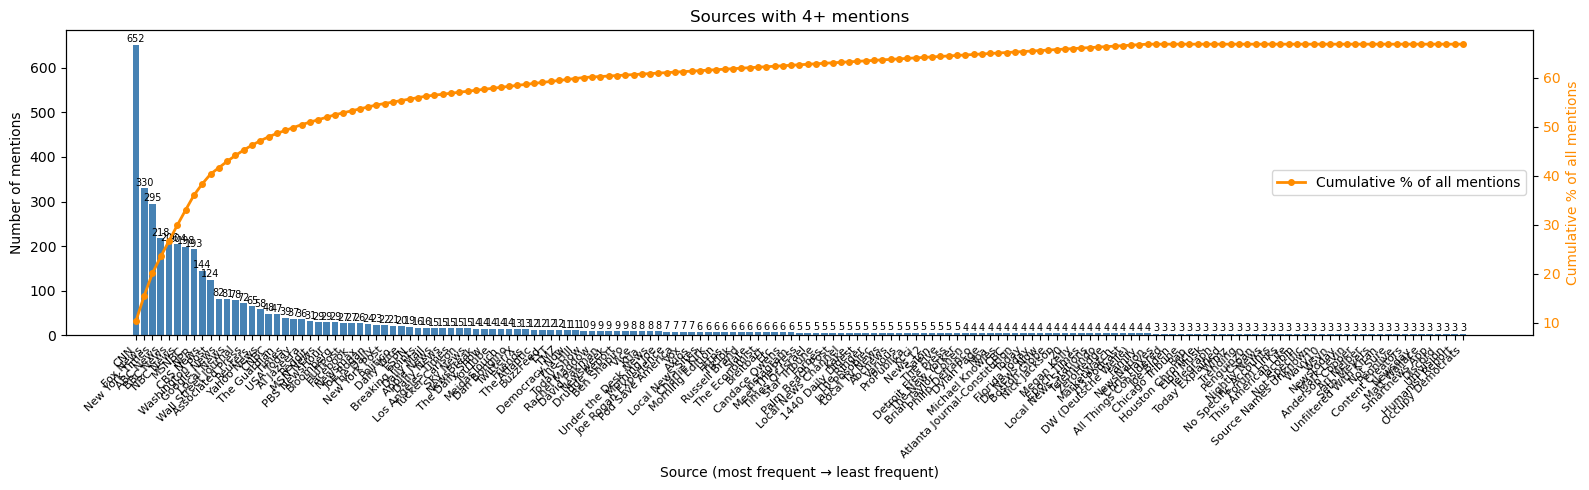

Total mentions in dataset: 6355

  Top  1 sources cover 652 of 6355 mentions (10.3%)
  Top  5 sources cover 1701 of 6355 mentions (26.8%)
  Top 10 sources cover 2564 of 6355 mentions (40.3%)
  Top 20 sources cover 3171 of 6355 mentions (49.9%)
  Top 40 sources cover 3626 of 6355 mentions (57.1%)
  Top 80 sources cover 3994 of 6355 mentions (62.8%)
  Top 161 sources cover 4300 of 6355 mentions (67.7%)


In [21]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = unified_freq['count'].sum()
top40 = unified_freq.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with 4+ mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top40['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")